# IMDb Movie Review Sentiment Analysis

In [1]:
%pip install -q datasets pandas matplotlib nltk scikit-learn

Note: you may need to restart the kernel to use updated packages.


## Environment and data

In [2]:
import sys
import datasets
import matplotlib
import nltk
import pandas as pd
import sklearn
from datasets import load_dataset

print(f"Python: {sys.version.split()[0]}")
print(f"datasets: {datasets.__version__}")
print(f"pandas: {pd.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"nltk: {nltk.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

dataset = load_dataset("stanfordnlp/imdb")

Python: 3.13.9
datasets: 5.0.1
pandas: 2.3.3
matplotlib: 3.10.6
nltk: 3.9.2
scikit-learn: 1.7.2


### Build the merged corpus

In [3]:
df_train = pd.DataFrame({"reviews": dataset["train"]["text"], "labels": dataset["train"]["label"]})
df_test = pd.DataFrame({"reviews": dataset["test"]["text"], "labels": dataset["test"]["label"]})

df = pd.concat([df_train, df_test]).reset_index(drop=True)
df

,reviews,labels
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0
...,...,...
49995,Just got around to seeing Monster Man yesterda...,1
49996,I got this as part of a competition prize. I w...,1
49997,I got Monster Man in a box set of three films ...,1
49998,"Five minutes in, i started to feel how naff th...",1


### Add readable sentiment labels

In [4]:
label_names = {0: "negative", 1: "positive"}
df["label_name"] = df['labels'].map(label_names)
df

,reviews,labels,label_name
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative
2,If only to avoid making this type of film in t...,0,negative
3,This film was probably inspired by Godard's Ma...,0,negative
4,"Oh, brother...after hearing about this ridicul...",0,negative
...,...,...,...
49995,Just got around to seeing Monster Man yesterda...,1,positive
49996,I got this as part of a competition prize. I w...,1,positive
49997,I got Monster Man in a box set of three films ...,1,positive
49998,"Five minutes in, i started to feel how naff th...",1,positive


### Inspect class balance

Dataset shape (rows, columns): (50000, 3)
Dataset columns: Index(['reviews', 'labels', 'label_name'], dtype='object')

Label distribution:

label_name
negative    25000
positive    25000
Name: count, dtype: int64



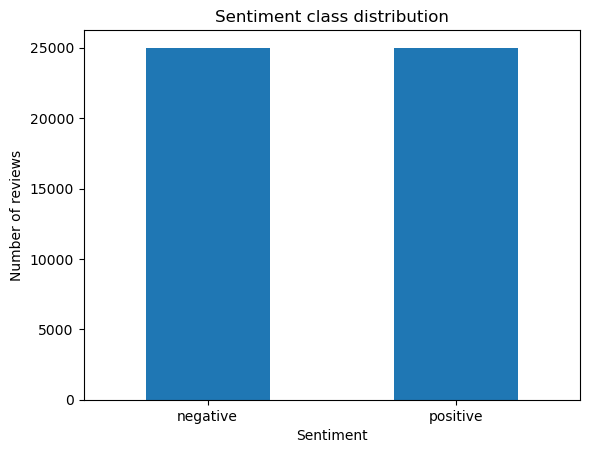

In [5]:
print(f"Dataset shape (rows, columns): {df.shape}")
print(f"Dataset columns: {df.columns}\n")

import matplotlib.pyplot as plt

label_distribution = df["label_name"].value_counts()
print(f"Label distribution:\n\n{label_distribution}\n")

label_distribution.plot(
    kind="bar",
    title="Sentiment class distribution",
    xlabel="Sentiment",
    ylabel="Number of reviews",
)
plt.xticks(rotation=0)
plt.show()

### Inspect a raw review

Review one original document before cleaning to make the transformation
performed by the preprocessing stage concrete.

In [6]:
print(df_train['reviews'][0])

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, eve

### Review-length distribution

In [7]:
df["reviews"].str.len().describe().round(2)

count    50000.00
mean      1309.43
std        989.73
min         32.00
25%        699.00
50%        970.00
75%       1590.25
max      13704.00
Name: reviews, dtype: float64

## Text preprocessing

Normalize HTML and whitespace, lowercase and tokenize the text, remove NLTK
English stop words and tokens of two or fewer characters, then lemmatize the
remaining tokens.

In [8]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package punkt to /Users/farouk-
[nltk_data]     dev/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/farouk-
[nltk_data]     dev/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/farouk-
[nltk_data]     dev/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/farouk-
[nltk_data]     dev/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [9]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

In [10]:
def preprocessor(review):
    review = re.sub(r'<br\s*/?>', ' ', review)
    review = re.sub(r'\s+', ' ', review).strip()
    tokens = word_tokenize(review.lower())
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(tokens)

print(f"Before preprocessing: {df['reviews'][0]}")
print(f"After preprocessing: {preprocessor(df['reviews'][0])}")

Before preprocessing: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are fe



#### **Before preprocessing**:

```I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, even then it's not shot like some cheaply made porno. While my countrymen mind find it shocking, in reality sex and nudity are a major staple in Swedish cinema. Even Ingmar Bergman, arguably their answer to good old boy John Ford, had sex scenes in his films.<br /><br />I do commend the filmmakers for the fact that any sex shown in the film is shown for artistic purposes rather than just to shock people and make money to be shown in pornographic theaters in America. I AM CURIOUS-YELLOW is a good film for anyone wanting to study the meat and potatoes (no pun intended) of Swedish cinema. But really, this film doesn't have much of a plot.```


#### **After preprocessing**:
```rented curious-yellow video store controversy surrounded first released 1967. also heard first seized u.s. custom ever tried enter country therefore fan film considered controversial really see plot centered around young swedish drama student named lena want learn everything life particular want focus attention making sort documentary average swede thought certain political issue vietnam war race issue united state asking politician ordinary denizen stockholm opinion politics sex drama teacher classmate married men kill curious-yellow year ago considered pornographic really sex nudity scene far even shot like cheaply made porno countryman mind find shocking reality sex nudity major staple swedish cinema even ingmar bergman arguably answer good old boy john ford sex scene film commend filmmaker fact sex shown film shown artistic purpose rather shock people make money shown pornographic theater america curious-yellow good film anyone wanting study meat potato pun intended swedish cinema really film n't much plot```



In [28]:
df["reviews"] = df["reviews"].apply(preprocessor)
df["reviews"]

33553    forget said emeril rachael ray irritating pers...
9427     former private eye-turned-security guard ditch...
199      mann photograph alberta rocky mountain superb ...
12447    simply put movie boring cliché upon cliché con...
39489    fan sci trailer film looked bit put hollywood ...
                               ...                        
11284    documentary use term loosely apparently summar...
44732    outlandish troma movie actually good movie kno...
38158    found film n't look basement good great charac...
860      read novel reaper ben mezrich year ago last ni...
15795    went see finnish film 've got say one better f...
Name: reviews, Length: 50000, dtype: object

### Validate preprocessing behavior

In [29]:
print(f"NLTK English stop-word list size: {len(stop_words)}")

NLTK English stop-word list size: 198


## Dataset partitioning

Shuffle deterministically with seed 42, create a fixed 40,000-review training
set and 10,000-review test set, then form nested 5,000-, 17,000-, and
40,000-review training scenarios.

In [13]:
from sklearn.utils import shuffle

df = shuffle(df, random_state=42)
df

,reviews,labels,label_name
33553,forget said emeril rachael ray irritating pers...,0,negative
9427,former private eye-turned-security guard ditch...,0,negative
199,mann photograph alberta rocky mountain superb ...,0,negative
12447,simply put movie boring cliché upon cliché con...,0,negative
39489,fan sci trailer film looked bit put hollywood ...,1,positive
...,...,...,...
11284,documentary use term loosely apparently summar...,0,negative
44732,outlandish troma movie actually good movie kno...,1,positive
38158,found film n't look basement good great charac...,1,positive
860,read novel reaper ben mezrich few year ago las...,0,negative


In [14]:
from sklearn.model_selection import train_test_split

train_full, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_5k = train_full.iloc[:5000]
train_17k = train_full.iloc[:17000]
train_40k = train_full.iloc[:40000]

print(f"5k shape: {train_5k.shape}")
print(f"17k shape: {train_17k.shape}")
print(f"40k shape: {train_40k.shape}")

5k shape: (5000, 3)
17k shape: (17000, 3)
40k shape: (40000, 3)


## TF-IDF feature representation

Fit a separate TF-IDF vectorizer on each training subset using unigrams and
bigrams, `min_df=2`, `max_df=0.95`, and a 30,000-feature limit. Transform the
fixed test set with each fitted training vocabulary.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

def vectorizer(train_df, test_df):
  tfidf_vectorizer = TfidfVectorizer(
      max_features=30000,
      ngram_range=(1, 2),
      min_df=2,
      max_df=0.95, # 95%
      lowercase=True
      )


  X_train = tfidf_vectorizer.fit_transform(train_df["reviews"])
  X_test = tfidf_vectorizer.transform(test_df["reviews"])

  return X_train, X_test, tfidf_vectorizer

In [16]:
X_train_5k, X_test_5k, vec_5k = vectorizer(train_5k, test_df)
X_train_17k, X_test_17k, vec_17k = vectorizer(train_17k, test_df)
X_train_40k, X_test_40k, vec_40k = vectorizer(train_40k, test_df)

print(f"5k - Train: {X_train_5k.shape}, Test: {X_test_5k.shape}")
print(f"17k - Train: {X_train_17k.shape}, Test: {X_test_17k.shape}")
print(f"40k - Train: {X_train_40k.shape}, Test: {X_test_40k.shape}")

5k - Train: (5000, 30000), Test: (10000, 30000)
17k - Train: (17000, 30000), Test: (10000, 30000)
40k - Train: (40000, 30000), Test: (10000, 30000)


### Vocabulary-size ablation

`max_features` on the 40,000-review

max_features=  1000  accuracy=0.8617  macro_f1=0.8617  fit_time=0.197s
max_features=  5000  accuracy=0.8867  macro_f1=0.8867  fit_time=0.365s
max_features= 30000  accuracy=0.8990  macro_f1=0.8990  fit_time=1.101s
max_features= 80000  accuracy=0.9063  macro_f1=0.9063  fit_time=0.328s


,max_features,accuracy,macro_f1,fit_time_seconds
0,1000,0.8617,0.8617,0.1971
1,5000,0.8867,0.8867,0.3648
2,30000,0.8990,0.8990,1.1010
3,80000,0.9063,0.9063,0.3277


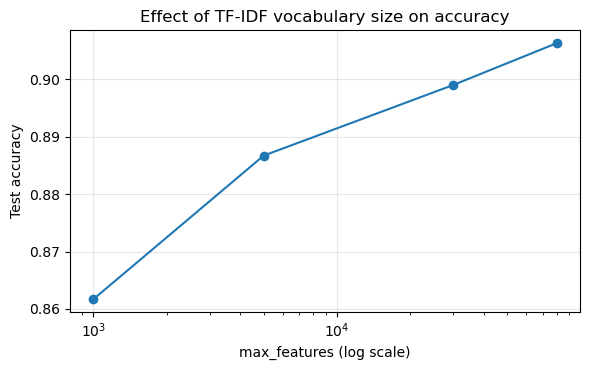

In [30]:
import time
from sklearn.metrics import accuracy_score, f1_score
from sklearn.svm import LinearSVC


def vectorizer_with_features(train_df, test_df, max_features):
    tfidf_vectorizer = TfidfVectorizer(
        max_features=max_features,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        lowercase=True,
    )
    X_train = tfidf_vectorizer.fit_transform(train_df["reviews"])
    X_test = tfidf_vectorizer.transform(test_df["reviews"])
    return X_train, X_test, tfidf_vectorizer


ablation_rows = []
for max_features in [1000, 5000, 30000, 80000]:
    X_train, X_test, vec = vectorizer_with_features(
        train_40k, test_df, max_features
    )
    model = LinearSVC()

    fit_start = time.perf_counter()
    
    model.fit(X_train, train_40k["labels"])
    
    fit_time_seconds = time.perf_counter() - fit_start

    predictions = model.predict(X_test)
    accuracy = accuracy_score(test_df["labels"], predictions)
    macro_f1 = f1_score(
        test_df["labels"], predictions, average="macro"
    )
    
    ablation_rows.append(
        {
            "max_features": max_features,
            "accuracy": accuracy,
            "macro_f1": macro_f1,
            "fit_time_seconds": fit_time_seconds,
        }
    )
    print(
        f"max_features={max_features:>6}  "
        f"accuracy={accuracy:.4f}  "
        f"macro_f1={macro_f1:.4f}  "
        f"fit_time={fit_time_seconds:.3f}s"
    )

ablation_df = pd.DataFrame(ablation_rows)
display(ablation_df.round(4))

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(ablation_df["max_features"], ablation_df["accuracy"], "o-")
ax.set_xscale("log")
ax.set_xlabel("max_features (log scale)")
ax.set_ylabel("Test accuracy")
ax.set_title("Effect of TF-IDF vocabulary size on accuracy")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## LinearSVC training

In [32]:
import time
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import LinearSVC


def train_linear_svc(X_train, y_train, X_test, y_test, name):
    
    fit_start = time.perf_counter()
    model = LinearSVC()
    model.fit(X_train, y_train)
    duration = time.perf_counter() - fit_start

    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    report = classification_report(
        y_test,
        predictions,
        target_names=["negative", "positive"],
        output_dict=True,
    )

    print(f"--- {name} ---")
    print(f"Training time: {duration:.2f} seconds")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score: {report['macro avg']['f1-score']:.4f}")
    print(f"Precision: {report['macro avg']['precision']:.4f}")
    print(f"Recall: {report['macro avg']['recall']:.4f}\n")

    return {
        "model": model,
        "duration": duration,
        "accuracy": accuracy,
        "f1": report["macro avg"]["f1-score"],
        "precision": report["macro avg"]["precision"],
        "recall": report["macro avg"]["recall"],
        "predictions": predictions,
    }

In [33]:
results_5k = train_linear_svc(X_train_5k, train_5k['labels'], X_test_5k, test_df['labels'], "5k Dataset")
results_17k = train_linear_svc(X_train_17k, train_17k['labels'], X_test_17k, test_df['labels'], "17k Dataset")
results_40k = train_linear_svc(X_train_40k, train_40k['labels'], X_test_40k, test_df['labels'], "40k Dataset")

--- 5k Dataset ---
Training time: 0.05 seconds
Accuracy: 0.8702
F1-Score: 0.8702
Precision: 0.8704
Recall: 0.8703

--- 17k Dataset ---
Training time: 0.12 seconds
Accuracy: 0.8898
F1-Score: 0.8898
Precision: 0.8899
Recall: 0.8898

--- 40k Dataset ---
Training time: 1.04 seconds
Accuracy: 0.8990
F1-Score: 0.8990
Precision: 0.8991
Recall: 0.8990



In [34]:
comparison_df = pd.DataFrame({
    "Dataset Size": ["5k", "17k", "40k"],
    "Training Time (s)": [results_5k['duration'], results_17k['duration'], results_40k['duration']],
    "Accuracy": [results_5k['accuracy'], results_17k['accuracy'], results_40k['accuracy']],
    "Precision": [
        classification_report(test_df['labels'], results_5k['predictions'], output_dict=True)['macro avg']['precision'],
        classification_report(test_df['labels'], results_17k['predictions'], output_dict=True)['macro avg']['precision'],
        classification_report(test_df['labels'], results_40k['predictions'], output_dict=True)['macro avg']['precision']
    ],
    "Recall": [
        classification_report(test_df['labels'], results_5k['predictions'], output_dict=True)['macro avg']['recall'],
        classification_report(test_df['labels'], results_17k['predictions'], output_dict=True)['macro avg']['recall'],
        classification_report(test_df['labels'], results_40k['predictions'], output_dict=True)['macro avg']['recall']
    ],
    "F1-Score": [results_5k['f1'], results_17k['f1'], results_40k['f1']]
})

display(comparison_df.round(4))

,Dataset Size,Training Time (s),Accuracy,Precision,Recall,F1-Score
0,5k,0.0465,0.8702,0.8704,0.8703,0.8702
1,17k,0.1172,0.8898,0.8899,0.8898,0.8898
2,40k,1.0409,0.8990,0.8991,0.8990,0.8990


### Performance against training-set size

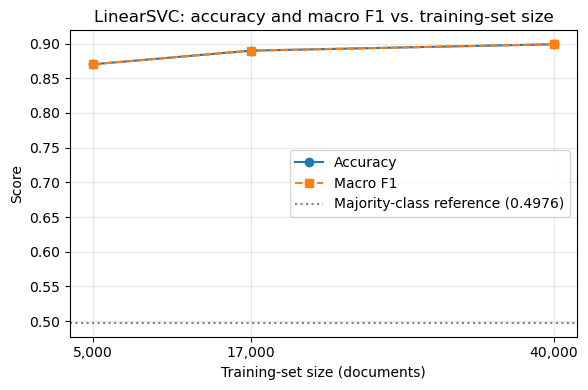

In [22]:
sizes = [5000, 17000, 40000]
svc_acc = [
    results_5k["accuracy"],
    results_17k["accuracy"],
    results_40k["accuracy"],
]
svc_f1 = [results_5k["f1"], results_17k["f1"], results_40k["f1"]]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sizes, svc_acc, "o-", label="Accuracy")
ax.plot(sizes, svc_f1, "s--", label="Macro F1")
ax.axhline(
    dummy_accuracy,
    color="grey",
    linestyle=":",
    label=f"Majority-class reference ({dummy_accuracy:.4f})",
)
ax.set_xlabel("Training-set size (documents)")
ax.set_ylabel("Score")
ax.set_title("LinearSVC: accuracy and macro F1 vs. training-set size")
ax.set_xticks(sizes)
ax.set_xticklabels([f"{size:,}" for size in sizes])
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### Confusion matrix of the strongest model

The 40,000-review LinearSVC is the strongest primary configuration

True negative:  4469
False positive: 555
False negative: 455
True positive:  4521
Correct: 8990 of 10000


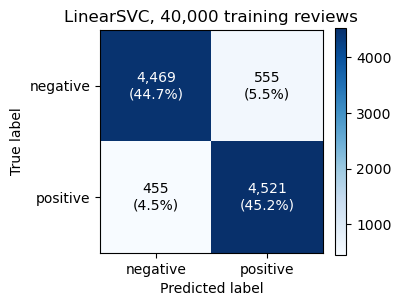


              precision    recall  f1-score   support

    negative     0.9076    0.8895    0.8985      5024
    positive     0.8907    0.9086    0.8995      4976

    accuracy                         0.8990     10000
   macro avg     0.8991    0.8990    0.8990     10000
weighted avg     0.8992    0.8990    0.8990     10000



In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_df["labels"], results_40k["predictions"])
tn, fp, fn, tp = cm.ravel()

print(f"True negative:  {tn}")
print(f"False positive: {fp}")
print(f"False negative: {fn}")
print(f"True positive:  {tp}")
print(f"Correct: {tn + tp} of {cm.sum()}")

fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], ["negative", "positive"])
ax.set_yticks([0, 1], ["negative", "positive"])
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("LinearSVC, 40,000 training reviews")
for row_index in range(2):
    for column_index in range(2):
        count = cm[row_index, column_index]
        percentage = count / cm.sum() * 100
        ax.text(
            column_index,
            row_index,
            f"{count:,}\n({percentage:.1f}%)",
            ha="center",
            va="center",
            color="white" if count > cm.max() / 2 else "black",
        )
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

print()
print(
    classification_report(
        test_df["labels"],
        results_40k["predictions"],
        target_names=["negative", "positive"],
        digits=4,
    )
)